Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Inicializaciones

In [2]:
#Dimensiones de la imagen a crear
ancho = 800
alto = 800

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

(800, 800, 1)


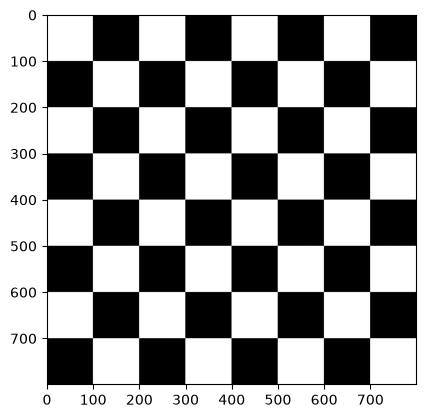

In [3]:
# Sin IA

#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,1), dtype = np.uint8)

casilla = 100
x1 = 0
x2 = 100
for i in range(0, 8):
    y1 = 0
    y2 = 100
    if i%2 != 0:
        y1 = 100
        y2 = 200
    for j in range(0, 4):
        color_img[x1:x2, y1:y2, 0] = 255
        y1 += 200
        y2 += 200
    x1 += 100
    x2 += 100

print(color_img.shape)


plt.imshow(color_img, cmap='gray') 
plt.show()

Dimensiones de la imagen: (800, 800, 1)


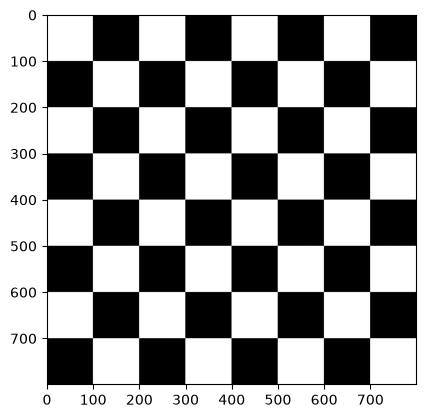

In [4]:
#Con IA

paso = 100

# 1. Generar matrices con las coordenadas de cada píxel
y, x = np.indices((alto, ancho))

# 2. Aplicar la lógica del ajedrez a toda la matriz simultáneamente
ajedrez_2d = (((y // paso) + (x // paso)) % 2 == 0).astype(np.uint8) * 128

# 3. Ajustar la forma para mantener el plano extra (800, 800, 1)
color_img = np.expand_dims(ajedrez_2d, axis=-1)

print("Dimensiones de la imagen:", color_img.shape)

plt.imshow(color_img, cmap='gray')
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

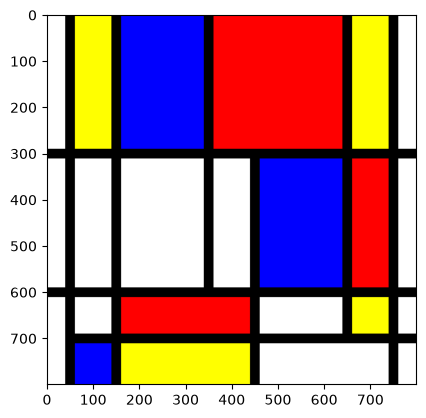

True

In [5]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)
color_img[:] = 255


#Rectángulos
cv2.rectangle(color_img,(60,0),(140,290),(255,255,0),-1)

cv2.rectangle(color_img,(160,0),(340,290),(0,0,255),-1)

cv2.rectangle(color_img,(360,0),(640,290),(255,0,0),-1)

cv2.rectangle(color_img,(660,0),(740,290),(255,255,0),-1)

cv2.rectangle(color_img,(460,310),(640,590),(0,0,255),-1)

cv2.rectangle(color_img,(660,310),(740,590),(255,0,0),-1)

cv2.rectangle(color_img,(160,610),(440,690),(255,0,0),-1)

cv2.rectangle(color_img,(660,610),(740,690),(255,255,0),-1)

cv2.rectangle(color_img,(60,710),(140,800),(0,0,255),-1)

cv2.rectangle(color_img,(160,710),(440,800),(255,255,0),-1)


#Líneas verticales
cv2.line(color_img,(50,0),(50,alto),(0,0,0),20)
cv2.line(color_img,(150,0),(150,alto),(0,0,0),20)
cv2.line(color_img,(350,0),(350,600),(0,0,0),20)
cv2.line(color_img,(450,300),(450,alto),(0,0,0),20)
cv2.line(color_img,(650,0),(650,700),(0,0,0),20)
cv2.line(color_img,(750,0),(750,alto),(0,0,0),20)

#Líneas horizontales
cv2.line(color_img,(0,300),(ancho,300),(0,0,0),20)
cv2.line(color_img,(0,600),(ancho,600),(0,0,0),20)
cv2.line(color_img,(50,700),(ancho,700),(0,0,0),20)
#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [7]:
# Lento con retardo Sin IA

import cv2
import numpy as np

vid = cv2.VideoCapture(0)


while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        h, w = frame_gris.shape 

        # 0 oscuro, 255 claro
        min_val = 255
        max_val = 0
        pos_min = (0, 0)
        pos_max = (0, 0)

        for y in range(0, h):
            for x in range(0, w):
                valor = frame_gris[y, x]

                if valor < min_val:
                        min_val = valor
                        pos_min = (x, y) # Guardamos coordenada para dibujar
                        
                if valor > max_val:
                    max_val = valor
                    pos_max = (x, y)
        cv2.circle(frame, pos_min, 15, (255, 0, 0), -1) # Azul oscuro
        cv2.circle(frame, pos_max, 15, (0, 0, 255), -1) # Rojo claro

        cv2.imshow('Vid', frame)
   
    if cv2.waitKey(20) == 27:
        break
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\interactiveshell.py", line 3823, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\naiar\AppData\Local\Temp\ipykernel_21104\1148863436.py", line None, in <module>
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\interactiveshell.py", line 2279, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\ultratb.py", line 1300, in structured_traceback
    return FormattedTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\naiar\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\ultratb.py", line 1166, in structured_traceback
    retu

In [8]:
# Acelerado y fluido con IA

import cv2
import numpy as np

vid = cv2.VideoCapture(0)

while(True):      
    ret, frame = vid.read()

    if ret: 
        # 1. Pasamos a escala de grises
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # 2. Búsqueda optimizada (Sustituye a todo tu bloque 'for')
        min_val, max_val, pos_min, pos_max = cv2.minMaxLoc(frame_gris)

        # 3. Dibujamos los círculos usando las posiciones devueltas
        cv2.circle(frame, pos_min, 15, (255, 0, 0), -1) # Azul en el más oscuro
        cv2.circle(frame, pos_max, 15, (0, 0, 255), -1) # Rojo en el más claro

        cv2.imshow('Vid', frame)
   
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [9]:
# Coger tiras verticales cambiarlas de orden y meterle un filtro en cada canal

import cv2
import numpy as np

vid = cv2.VideoCapture(0)
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
collage = np.zeros((h,w,3), dtype = np.uint8)

# Para que tordos los cortes sean iguales
tercio = int(w/3)
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:

        collage[:, 0:tercio, 0] = frame[:, tercio*2:tercio*3, 2]
        collage[:, 0:tercio, 1] = frame[:, tercio*2:tercio*3, 1]
        collage[:, 0:tercio, 2] = frame[:, tercio*2:tercio*3, 0]

        collage[:, tercio:tercio*2, 0] = 255 - frame[:, 0:tercio, 2]
        collage[:, tercio:tercio*2, 1] = frame[:, 0:tercio, 1]
        collage[:, tercio:tercio*2, 2] = frame[:, 0:tercio, 0]
        
        collage[:, tercio*2:tercio*3, 0] = frame[:, tercio:tercio*2, 2]
        collage[:, tercio*2:tercio*3, 1] = 255 - frame[:, tercio:tercio*2, 0]
        collage[:, tercio*2:tercio*3, 2] = frame[:, tercio:tercio*2, 1]


        cv2.imshow('Vid', collage)
   
    if cv2.waitKey(20) == 27:
        break
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 